# N25 - Final frozen TEST evaluation

## 25.1 Purpose and epistemic status

**N25 is the first notebook in the revised frozen application pipeline permitted to evaluate realised TEST economic outcomes after the N24 policy freeze. Historical TEST-period outputs had been inspected during earlier project development, including earlier empirical/application work. The broader TEST period is therefore not claimed to be globally untouched. However, after the revised application design and N24 freeze, no new application model, hyperparameter, feature, gate, threshold or policy selection was performed using TEST economic outcomes.**

C and VALIDATION are development-stage evidence. C is the fitting block and VALIDATION is the pre-TEST model-selection/diagnostic block. TEST is reported separately and is not pooled with either development block as the primary result.

A favourable TEST result following adverse VALIDATION evidence is interpreted as temporal/regime dependence rather than evidence of a stable profitable strategy. An adverse TEST result provides further evidence consistent with weak or non-robust economic value. There is no methodologically preferred TEST outcome: the evidential value comes from evaluating the frozen specification rather than from obtaining a favourable result.

## 25.2 Imports, paths and frozen provenance setup

## 25.3 Frozen N24 specification and TEST handoff

## 25.4 Pre-outcome freeze gate

In [8]:
from pathlib import Path
import hashlib, datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display, Markdown

PROJECT=Path.cwd().resolve()
if not (PROJECT/'Data').is_dir(): PROJECT=PROJECT/'CODEWORK'/"Linus' Task Re-Do"
PROCESSED,FIGURES=PROJECT/'Data'/'processed',PROJECT/'figures'; FIGURES.mkdir(exist_ok=True)
EXECUTION_START=dt.datetime.now(dt.timezone.utc)
def sha(p): return hashlib.sha256(Path(p).read_bytes()).hexdigest()
def read(name,**kw): return pd.read_csv(PROCESSED/name,**kw)
PRED=['Yhat_BASE','Yhat_HIDDEN_AWARE','Yhat_NOISE_19','Yhat_NOISE_119','Yhat_NOISE_219']
ACT=['z_BASE','z_GATE_ONLY','z_HIDDEN_RAW','z_HIDDEN_AWARE']; KEY='decision_model_day'
# Explicit canonical upstream N14-N24 set, including optional N18A.
up=[]
for x in ['14_','15_','16_','17_','18_','19_','20_','21_','22_','23_','24_']:
    q=sorted(PROJECT.glob(x+'*.ipynb')); assert len(q)==1,(x,q); up+=q
up+=sorted(PROJECT.glob('18A_*.ipynb'))
UP_BEFORE={p.name:sha(p) for p in up}
N24=PROJECT/'24_application_gradient_boosting_and_policy_freeze.ipynb'
SPEC=PROCESSED/'24_frozen_application_specification.csv'; HANDOFF=PROCESSED/'24_test_prediction_policy_handoff.csv'; MANIFEST=PROCESSED/'24_export_manifest.csv'
HANDOFF_HASH_START=sha(HANDOFF); SPEC_HASH_START=sha(SPEC); N24_HASH_START=sha(N24)
HANDOFF_MTIME=dt.datetime.fromtimestamp(HANDOFF.stat().st_mtime,dt.timezone.utc)
assert HANDOFF_MTIME < EXECUTION_START
spec=read(SPEC); manifest=read('24_export_manifest.csv')
handoff=read('24_test_prediction_policy_handoff.csv',parse_dates=[KEY,'forecast_target_model_day']).sort_values(KEY).reset_index(drop=True)
assert len(spec)==1 and len(handoff)==901 and handoff[KEY].is_unique and handoff.stage.eq('TEST').all()
assert np.isfinite(handoff[PRED].to_numpy(float)).all()
assert not any(c in handoff.columns for c in ['Y_gross','Y_net_L','Y_net_S','Pi_gross','payoff_T','hedge_pnl_mid'])
assert spec.loc[0,'target']=='Y_gross'
assert spec.loc[0,'BASE_features']=='Q_t | R_t | I_t | Fhat_R_adm_t1 | Fhat_I_adm_t1 | S_t1_given_t'
assert spec.loc[0,'HIDDEN_AWARE_additions']=='Delta_L_t | common_log_response_t | P_R_t | P_I_prev_t'
assert '>=3' in spec.loc[0,'support_rule'] and 'squared_error' in spec.loc[0,'GB_parameters'] and 'random_state' in spec.loc[0,'GB_parameters'] and '250' in spec.loc[0,'GB_parameters'] and '0.03' in spec.loc[0,'GB_parameters']
assert spec.loc[0,'noise_seeds']=='19 | 119 | 219' and float(spec.loc[0,'s_sigma_vol_points'])==.2
assert spec.loc[0,'gate_only']=='z_BASE * G_t' and spec.loc[0,'hidden_aware']=='z_HIDDEN_RAW * G_t'
assert (handoff.z_GATE_ONLY==handoff.z_BASE*handoff.G_t).all() and (handoff.z_HIDDEN_AWARE==handoff.z_HIDDEN_RAW*handoff.G_t).all()
# GATE_ONLY is evaluated solely through its frozen action identity below; it has no separate application estimator.
SNAP_COLS=[KEY,'forecast_target_model_day','stage','G_t','c_entry_L','c_entry_S',*PRED,*ACT]
handoff_snapshot=handoff[SNAP_COLS].copy(deep=True).sort_values(KEY).reset_index(drop=True)
# Determine whether this manifest actually records a SHA256 for this handoff; do not infer from an arbitrary column name.
manifest_file_col=next((c for c in manifest.columns if c.lower()=='file'),None)
manifest_hash_col=next((c for c in manifest.columns if c.lower() in {'sha256','sha_256','sha-256'}),None)
manifest_handoff_row=manifest[manifest[manifest_file_col].eq(HANDOFF.name)] if manifest_file_col else pd.DataFrame()
prior_hash_available=bool(manifest_hash_col and len(manifest_handoff_row) and pd.notna(manifest_handoff_row.iloc[0][manifest_hash_col]) and str(manifest_handoff_row.iloc[0][manifest_hash_col]).strip())
prior_handoff_hash=str(manifest_handoff_row.iloc[0][manifest_hash_col]).strip() if prior_hash_available else None
if prior_hash_available:
    assert prior_handoff_hash==HANDOFF_HASH_START
    provenance_status='VERIFIED_AGAINST_N24_HASH'
else:
    assert HANDOFF_MTIME < EXECUTION_START
    provenance_status='LIMITED-BUT-DOCUMENTED'
pre_outcome_audit=pd.DataFrame([{'execution_start_utc':EXECUTION_START.isoformat(),'handoff_rows':len(handoff),'handoff_unique_days':handoff[KEY].nunique(),'handoff_sha256_start':HANDOFF_HASH_START,'spec_sha256_start':SPEC_HASH_START,'N24_notebook_sha256_start':N24_HASH_START,'prior_N24_handoff_hash_available':prior_hash_available,'provenance_status':provenance_status,'handoff_mtime_precedes_N25_start':HANDOFF_MTIME<EXECUTION_START,'TEST_outcomes_loaded_pre_gate':False,'gate_rows_surviving_COMMON':int(handoff.G_t.sum())}])
print('PRE-OUTCOME N25 FREEZE GATE: PASS')
print('Frozen handoff rows / gate rows:',len(handoff),int(handoff.G_t.sum()),'; prior N24 handoff hash available:',prior_hash_available)


PRE-OUTCOME N25 FREEZE GATE: PASS
Frozen handoff rows / gate rows: 901 74 ; prior N24 handoff hash available: False


## 25.5 Open and reconcile TEST outcomes

## 25.6 TEST target and predictive evaluation

In [9]:
# TEST outcomes are opened only after the preceding gate printed PASS.
cols=['model_day','stage','s_sigma_label','Y_gross','Y_net_L','Y_net_S','c_opt_L','c_opt_S','c_spot_total_L','c_spot_total_S','entry_hurdle_uses_future_information']
out=read('23_cost_grid_panel.csv',parse_dates=['model_day'],usecols=cols)
out=out[(out.stage=='TEST') & (out.s_sigma_label=='BASE')].copy()
assert len(out)==962 and out.model_day.is_unique and out.entry_hurdle_uses_future_information.eq(False).all()
for c in ['Y_gross','Y_net_L','Y_net_S','c_opt_L','c_opt_S','c_spot_total_L','c_spot_total_S']: out[c]=pd.to_numeric(out[c],errors='raise')
evalp=handoff.merge(out.drop(columns=['stage','s_sigma_label']).rename(columns={'model_day':KEY}),on=KEY,how='left',validate='one_to_one',indicator=True)
assert len(evalp)==901 and evalp._merge.eq('both').all() and evalp[KEY].is_unique and evalp[['Y_gross','Y_net_L','Y_net_S']].notna().all().all()
evalp=evalp.drop(columns='_merge')
assert evalp.forecast_target_model_day.notna().all()
post_merge_snapshot=evalp[SNAP_COLS].copy().sort_values(KEY).reset_index(drop=True)
post_merge_float_equal=all(np.allclose(post_merge_snapshot[col],handoff_snapshot[col],rtol=0,atol=1e-12,equal_nan=True) for col in ['c_entry_L','c_entry_S',*PRED])
post_merge_discrete_equal=all(post_merge_snapshot[col].equals(handoff_snapshot[col]) for col in [KEY,'forecast_target_model_day','stage','G_t',*ACT])
post_merge_snapshot_equal=bool(post_merge_float_equal and post_merge_discrete_equal)
assert post_merge_snapshot_equal

def pred_metrics(y,h):
 e=np.asarray(y,float)-np.asarray(h,float); ae=np.abs(e); se=e**2
 return {'MSE':float(se.mean()),'RMSE':float(np.sqrt(se.mean())),'MAE':float(ae.mean()),'median_absolute_error':float(np.median(ae)),'correlation':float(np.corrcoef(y,h)[0,1]) if np.std(h)>0 else np.nan,'mean_prediction':float(np.mean(h)),'median_prediction':float(np.median(h)),'SSE':float(se.sum())}
def counts(z):
 z=np.asarray(z,int); n=int((z!=0).sum()); return {'n_long':int((z==1).sum()),'n_flat':int((z==0).sum()),'n_short':int((z==-1).sum()),'n_trades':n,'long_share_conditional_trading':float((z==1).sum()/n) if n else np.nan,'short_share_conditional_trading':float((z==-1).sum()/n) if n else np.nan}
def pnl(z): return np.where(np.asarray(z)==1,evalp.Y_net_L,np.where(np.asarray(z)==-1,evalp.Y_net_S,0.))
def econ(z):
 p=np.asarray(pnl(z),float); tr=np.asarray(z)!=0; cum=np.cumsum(p); dd=cum-np.maximum.accumulate(np.r_[0.,cum])[1:]; sd=float(np.std(p,ddof=1))
 return {'n_days':len(p),**counts(z),'mean_daily_net_pnl':float(p.mean()),'median_daily_net_pnl':float(np.median(p)),'std_daily_net_pnl':sd,'best_day':float(p.max()),'worst_day':float(p.min()),'mean_net_pnl_conditional_trading':float(p[tr].mean()) if tr.any() else np.nan,'median_net_pnl_conditional_trading':float(np.median(p[tr])) if tr.any() else np.nan,'trade_hit_rate':float((p[tr]>0).mean()) if tr.any() else np.nan,'cumulative_net_pnl':float(cum[-1]),'maximum_drawdown':float(dd.min()),'J':float(p.mean()/sd) if sd>0 else np.nan}

y=evalp.Y_gross.to_numpy(float); predictions={'ZERO_FORECAST':np.zeros(len(evalp)),'BASE':evalp.Yhat_BASE,'HIDDEN_AWARE':evalp.Yhat_HIDDEN_AWARE,'BASE_NOISE_19':evalp.Yhat_NOISE_19,'BASE_NOISE_119':evalp.Yhat_NOISE_119,'BASE_NOISE_219':evalp.Yhat_NOISE_219}
predictive=pd.DataFrame([{'model':m,**pred_metrics(y,h)} for m,h in predictions.items()])
predictive.loc[predictive.model.eq('ZERO_FORECAST'),'correlation']=np.nan
zero=float(predictive.loc[predictive.model.eq('ZERO_FORECAST'),'MSE'].iloc[0]); base=float(predictive.loc[predictive.model.eq('BASE'),'MSE'].iloc[0]); hidden=float(predictive.loc[predictive.model.eq('HIDDEN_AWARE'),'MSE'].iloc[0])
predictive['delta_MSE_vs_ZERO']=predictive.MSE-zero; predictive['delta_MSE_vs_BASE']=predictive.MSE-base
hierarchy=predictive.sort_values('MSE')[['model','MSE']].reset_index(drop=True); hierarchy['MSE_rank']=hierarchy.index+1


## 25.7 Tail-concentration diagnostics

## 25.8 Frozen policy construction and economic metrics

In [10]:
# Tail concentration.
conc=[]; tops=[]
for name,col in [('BASE','Yhat_BASE'),('HIDDEN_AWARE','Yhat_HIDDEN_AWARE')]:
 q=evalp[[KEY,'Y_gross',col]].copy(); q['absolute_error']=(q.Y_gross-q[col]).abs(); q['squared_error']=q.absolute_error**2; q=q.sort_values('squared_error',ascending=False).reset_index(drop=True); total=q.squared_error.sum(); q['share_of_total_SSE']=q.squared_error/total; q['rank']=q.index+1
 conc.append({'model':name,'largest_single_SSE_share':float(q.share_of_total_SSE.iloc[0]),'top_5_SSE_share':float(q.share_of_total_SSE.head(5).sum()),'top_10_SSE_share':float(q.share_of_total_SSE.head(10).sum()),'top_20_SSE_share':float(q.share_of_total_SSE.head(20).sum())}); tops.append(q.head(10).rename(columns={col:'prediction'}).assign(model=name)[['model','rank',KEY,'Y_gross','prediction','absolute_error','squared_error','share_of_total_SSE']])
concentration=pd.DataFrame(conc); top_errors=pd.concat(tops,ignore_index=True)
# Exact frozen policies, plus declared fixed benchmarks.
pol={'BASE':evalp.z_BASE.to_numpy(int),'GATE_ONLY':evalp.z_GATE_ONLY.to_numpy(int),'HIDDEN_AWARE':evalp.z_HIDDEN_AWARE.to_numpy(int),'FLAT':np.zeros(len(evalp),int),'ALWAYS_LONG':np.ones(len(evalp),int),'ALWAYS_SHORT':-np.ones(len(evalp),int),'GATED_ALWAYS_LONG':evalp.G_t.to_numpy(int),'GATED_ALWAYS_SHORT':-evalp.G_t.to_numpy(int)}
actions=pd.DataFrame([{'policy':k,**counts(z)} for k,z in pol.items()]); economics=pd.DataFrame([{'policy':k,**econ(z)} for k,z in pol.items()])
def mapping_ok(z,p):
    z=np.asarray(z); p=np.asarray(p,float); yl=evalp.Y_net_L.to_numpy(float); ys=evalp.Y_net_S.to_numpy(float)
    return bool(np.allclose(p[z==1],yl[z==1],rtol=0,atol=1e-12) and np.allclose(p[z==-1],ys[z==-1],rtol=0,atol=1e-12) and np.allclose(p[z==0],0.,rtol=0,atol=1e-12))
policy_mapping_checks={name:mapping_ok(z,pnl(z)) for name,z in pol.items()}
assert all(policy_mapping_checks.values())


## 25.9 Gate-timing diagnostic

$$\Pi^{BASE}_t = \alpha + \gamma G_t + \epsilon_t$$

The economic experiment was frozen before N25: forecasting models, features, gate, policy rules, cost treatment and benchmarks were fixed in N24. The HAC and moving-block-bootstrap calculations below are supporting post-freeze inferential diagnostics, not pre-registered primary tests. Earlier planning considered additional full-chronology paired inference, but it was not incorporated into the final frozen N22/N24 application specification and is not reported here.

In [11]:
# Conditional gate timing on BASE trade days only.
base_pnl=pnl(pol['BASE']); trade=evalp.z_BASE.ne(0).to_numpy(); gt=evalp.G_t.to_numpy(int); sub=pd.DataFrame({'BASE_policy_net_pnl':base_pnl[trade],'G_t':gt[trade]})
assert sub.G_t.isin([0,1]).all() and (sub.G_t==1).any() and (sub.G_t==0).any()
groups=sub.groupby('G_t').BASE_policy_net_pnl.agg(['size','mean','median','std',lambda x:float((x>0).mean())]); groups.columns=['n','mean','median','std','hit_rate']
delta=float(groups.loc[1,'mean']-groups.loc[0,'mean']); fit=sm.OLS(sub.BASE_policy_net_pnl,sm.add_constant(sub.G_t)).fit(cov_type='HAC',cov_kwds={'maxlags':5}); ci=fit.conf_int().loc['G_t']
gate_timing=pd.DataFrame([{'n_BASE_trade_days':len(sub),'n_BASE_trade_days_G1':int(groups.loc[1,'n']),'n_BASE_trade_days_G0':int(groups.loc[0,'n']),'G1_mean':float(groups.loc[1,'mean']),'G0_mean':float(groups.loc[0,'mean']),'raw_mean_difference':delta,'alpha':float(fit.params['const']),'gamma':float(fit.params['G_t']),'HAC_SE_gamma':float(fit.bse['G_t']),'HAC_t_gamma':float(fit.tvalues['G_t']),'HAC_p_gamma':float(fit.pvalues['G_t']),'HAC_CI_low':float(ci.iloc[0]),'HAC_CI_high':float(ci.iloc[1])}])
# Supporting chronological moving-block bootstrap diagnostic (ordinary overlapping blocks; no wraparound).
rng=np.random.default_rng(19); n=len(sub); B=10000; dif=[]
for _ in range(B):
 idx=[]
 while len(idx)<n:
  start=int(rng.integers(0,n-5+1)); idx.extend(np.arange(start,start+5))
 b=sub.iloc[np.array(idx[:n])]
 if b.G_t.nunique()==2: dif.append(float(b.loc[b.G_t.eq(1),'BASE_policy_net_pnl'].mean()-b.loc[b.G_t.eq(0),'BASE_policy_net_pnl'].mean()))
boot=np.asarray(dif); gate_bootstrap=pd.DataFrame([{'block_length_BASE_trade_observations':5,'replications_requested':B,'random_seed':19,'valid_replications':len(boot),'mean_difference':float(boot.mean()),'median_difference':float(np.median(boot)),'p02_5':float(np.quantile(boot,.025)),'p97_5':float(np.quantile(boot,.975))}])
# Gate-only -> hidden paired incremental analysis on gated rows only.
g=evalp.G_t.eq(1).to_numpy(); d=pnl(pol['HIDDEN_AWARE'])[g]-pnl(pol['GATE_ONLY'])[g]; gf=sm.OLS(d,np.ones((len(d),1))).fit(cov_type='HAC',cov_kwds={'maxlags':5}); gci=gf.conf_int()[0]
paired=pd.DataFrame([{'n_gated':int(g.sum()),'GATE_ONLY_n_trades':int((pol['GATE_ONLY'][g]!=0).sum()),'HIDDEN_AWARE_n_trades':int((pol['HIDDEN_AWARE'][g]!=0).sum()),'action_agreements':int((pol['GATE_ONLY'][g]==pol['HIDDEN_AWARE'][g]).sum()),'action_disagreements':int((pol['GATE_ONLY'][g]!=pol['HIDDEN_AWARE'][g]).sum()),'action_disagreement_pct':float((pol['GATE_ONLY'][g]!=pol['HIDDEN_AWARE'][g]).mean()),'mean_D':float(d.mean()),'median_D':float(np.median(d)),'std_D':float(np.std(d,ddof=1)),'n_D_gt_0':int((d>0).sum()),'n_D_eq_0':int((d==0).sum()),'n_D_lt_0':int((d<0).sum()),'cumulative_D':float(d.sum()),'mu_gate':float(gf.params[0]),'HAC_SE':float(gf.bse[0]),'HAC_t':float(gf.tvalues[0]),'HAC_p':float(gf.pvalues[0]),'HAC_CI_low':float(gci[0]),'HAC_CI_high':float(gci[1]),'gate_frequency':float(g.mean()),'deployment_scaled_mean':float(gf.params[0]*g.mean()),'full_chronology_cumulative_difference':float(economics.set_index('policy').loc['HIDDEN_AWARE','cumulative_net_pnl']-economics.set_index('policy').loc['GATE_ONLY','cumulative_net_pnl'])}])


## 25.10 Hidden-aware incremental paired diagnostic

$$D_t = \Pi_t^{HIDDEN\_AWARE}-\Pi_t^{GATE\_ONLY}$$

## 25.11 Transaction-cost diagnostic

The frozen entry rule accounts only for costs observable at the decision boundary, whereas realised net PnL also incorporates subsequent hedge rebalancing and terminal-unwind costs. The ex-post implementation burden is therefore materially larger than the entry hurdle by construction. Negative net PnL is not pure evidence of signal absence: predictive weakness is already visible before economic implementation, while realised transaction costs further increase the hurdle for profitability.

In [12]:
# Target and friction distributions.
target=pd.DataFrame([{'n':len(evalp),'mean_Y_gross':float(evalp.Y_gross.mean()),'median_Y_gross':float(evalp.Y_gross.median()),'std_Y_gross':float(evalp.Y_gross.std(ddof=1)),'minimum_Y_gross':float(evalp.Y_gross.min()),'maximum_Y_gross':float(evalp.Y_gross.max()),'q05':float(evalp.Y_gross.quantile(.05)),'q10':float(evalp.Y_gross.quantile(.1)),'q25':float(evalp.Y_gross.quantile(.25)),'q75':float(evalp.Y_gross.quantile(.75)),'q90':float(evalp.Y_gross.quantile(.9)),'q95':float(evalp.Y_gross.quantile(.95)),'fraction_gt_0':float((evalp.Y_gross>0).mean()),'fraction_lt_0':float((evalp.Y_gross<0).mean())}])
option_cost=(evalp.c_opt_L+evalp.c_opt_S)/2
spot_cost=(evalp.c_spot_total_L+evalp.c_spot_total_S)/2
implementation_cost=option_cost+spot_cost
friction=pd.DataFrame([{'median_option_entry_cost':float(option_cost.median()),'median_total_spot_hedging_cost':float(spot_cost.median()),'median_total_implementation_cost':float(implementation_cost.median()),'median_implementation_cost_to_abs_Ygross':float((implementation_cost/evalp.Y_gross.abs()).replace([np.inf,-np.inf],np.nan).median())}])
display(target); display(predictive); display(hierarchy); display(concentration); display(top_errors); display(actions); display(economics); display(gate_timing); display(gate_bootstrap); display(paired); display(friction)


,n,mean_Y_gross,median_Y_gross,std_Y_gross,minimum_Y_gross,maximum_Y_gross,q05,q10,q25,q75,q90,q95,fraction_gt_0,fraction_lt_0
0,901,-0.001552,-0.062881,0.467217,-0.887941,4.308937,-0.577641,-0.446598,-0.25816,0.149751,0.450815,0.771104,0.429523,0.570477


,model,MSE,RMSE,MAE,median_absolute_error,correlation,mean_prediction,median_prediction,SSE,delta_MSE_vs_ZERO,delta_MSE_vs_BASE
0,ZERO_FORECAST,0.218052,0.466960,0.299032,0.208455,NaN,0.000000,0.000000,196.464738,0.000000,-0.005395
1,BASE,0.223447,0.472701,0.298570,0.202275,-0.003139,-0.024906,-0.028362,201.325328,0.005395,0.000000
2,HIDDEN_AWARE,0.224952,0.474291,0.299723,0.204357,-0.005833,-0.030078,-0.035644,202.681355,0.006900,0.001505
3,BASE_NOISE_19,0.222157,0.471336,0.298240,0.202184,0.010386,-0.024847,-0.026399,200.163778,0.004105,-0.001289
4,BASE_NOISE_119,0.222519,0.471719,0.299021,0.205064,0.007023,-0.024180,-0.026225,200.489854,0.004467,-0.000927
5,BASE_NOISE_219,0.225225,0.474579,0.298747,0.198435,-0.017444,-0.027707,-0.025715,202.927788,0.007173,0.001779


,model,MSE,MSE_rank
0,ZERO_FORECAST,0.218052,1
1,BASE_NOISE_19,0.222157,2
2,BASE_NOISE_119,0.222519,3
3,BASE,0.223447,4
4,HIDDEN_AWARE,0.224952,5
5,BASE_NOISE_219,0.225225,6


,model,largest_single_SSE_share,top_5_SSE_share,top_10_SSE_share,top_20_SSE_share
0,BASE,0.094499,0.300225,0.386964,0.467842
1,HIDDEN_AWARE,0.093142,0.298679,0.388687,0.470663


,model,rank,decision_model_day,Y_gross,prediction,absolute_error,squared_error,share_of_total_SSE
0,BASE,1,2022-10-20,4.248601,-0.113174,4.361775,19.025081,0.094499
1,BASE,2,2025-08-21,4.308937,0.020600,4.288337,18.389834,0.091344
2,BASE,3,2024-07-10,3.097107,-0.000994,3.098102,9.598234,0.047675
3,BASE,4,2023-07-26,2.651393,-0.020494,2.671888,7.138984,0.035460
4,BASE,5,2022-12-19,2.480866,-0.027269,2.508135,6.290741,0.031247
5,BASE,6,2022-09-21,2.188758,-0.064081,2.252840,5.075287,0.025209
6,BASE,7,2026-05-05,2.016892,-0.032202,2.049093,4.198784,0.020856
7,BASE,8,2022-07-26,1.625199,-0.048435,1.673635,2.801053,0.013913
8,BASE,9,2024-01-30,1.759295,0.099841,1.659454,2.753788,0.013678
9,BASE,10,2024-09-26,1.558861,-0.064081,1.622942,2.633941,0.013083


...

,policy,n_days,n_long,n_flat,n_short,n_trades,long_share_conditional_trading,short_share_conditional_trading,mean_daily_net_pnl,median_daily_net_pnl,std_daily_net_pnl,best_day,worst_day,mean_net_pnl_conditional_trading,median_net_pnl_conditional_trading,trade_hit_rate,cumulative_net_pnl,maximum_drawdown,J
0,BASE,901,203,181,517,720,0.281944,0.718056,-0.053650,0.000000,0.431458,4.145413,-4.421362,-0.067137,-0.024978,0.466667,-48.338620,-50.809259,-0.124346
1,GATE_ONLY,901,24,837,40,64,0.375000,0.625000,-0.004718,0.000000,0.119698,1.015170,-2.065447,-0.066426,-0.048391,0.437500,-4.251242,-5.382523,-0.039419
2,HIDDEN_AWARE,901,25,832,44,69,0.362319,0.637681,-0.006088,0.000000,0.125648,0.627087,-2.065447,-0.079500,-0.025911,0.478261,-5.485496,-6.789655,-0.048455
3,FLAT,901,0,901,0,0,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN
4,ALWAYS_LONG,901,901,0,0,901,1.000000,0.000000,-0.065275,-0.119145,0.461633,4.145413,-0.983206,-0.065275,-0.119145,0.327414,-58.812969,-59.319653,-0.141401
5,ALWAYS_SHORT,901,0,0,901,901,0.000000,1.000000,-0.062171,-0.006343,0.475661,0.870104,-4.472460,-0.062171,-0.006343,0.492786,-56.015881,-67.193928,-0.130704
6,GATED_ALWAYS_LONG,901,74,827,0,74,1.000000,0.000000,-0.005620,0.000000,0.123715,1.968337,-0.674714,-0.068424,-0.102197,0.351351,-5.063363,-7.087356,-0.045425
7,GATED_ALWAYS_SHORT,901,0,827,74,74,0.000000,1.000000,-0.004101,0.000000,0.129114,0.605781,-2.065447,-0.049931,-0.011778,0.472973,-3.694900,-5.384944,-0.031762


,n_BASE_trade_days,n_BASE_trade_days_G1,n_BASE_trade_days_G0,G1_mean,G0_mean,raw_mean_difference,alpha,gamma,HAC_SE_gamma,HAC_t_gamma,HAC_p_gamma,HAC_CI_low,HAC_CI_high
0,720,64,656,-0.066426,-0.067206,0.000781,-0.067206,0.000781,0.055881,0.013971,0.988853,-0.108744,0.110306


,block_length_BASE_trade_observations,replications_requested,random_seed,valid_replications,mean_difference,median_difference,p02_5,p97_5
0,5,10000,19,10000,0.00133,0.002691,-0.11198,0.109974


,n_gated,GATE_ONLY_n_trades,HIDDEN_AWARE_n_trades,action_agreements,action_disagreements,action_disagreement_pct,mean_D,median_D,std_D,n_D_gt_0,...,cumulative_D,mu_gate,HAC_SE,HAC_t,HAC_p,HAC_CI_low,HAC_CI_high,gate_frequency,deployment_scaled_mean,full_chronology_cumulative_difference
0,74,64,69,53,21,0.283784,-0.016679,0.0,0.377091,11,...,-1.234254,-0.016679,0.040888,-0.407918,0.683334,-0.096819,0.063461,0.082131,-0.00137,-1.234254


,median_option_entry_cost,median_total_spot_hedging_cost,median_total_implementation_cost,median_implementation_cost_to_abs_Ygross
0,0.01002,0.04378,0.053942,0.280411


## 25.12 Cross-stage comparison

## 25.13 TEST figures

,stage,n,mean_Y_gross,median_Y_gross,ZERO_MSE,ZERO_correlation,BASE_MSE,BASE_correlation,HIDDEN_AWARE_MSE,HIDDEN_AWARE_correlation,...,GATE_ONLY_n_long,GATE_ONLY_n_flat,GATE_ONLY_n_short,GATE_ONLY_cumulative_net_pnl,GATE_ONLY_J,HIDDEN_AWARE_n_long,HIDDEN_AWARE_n_flat,HIDDEN_AWARE_n_short,HIDDEN_AWARE_cumulative_net_pnl,HIDDEN_AWARE_J
0,C,805,-0.073699,-0.088768,0.123682,NaN,0.105302,0.399130,0.100247,0.477920,...,3,742,60,4.115611,0.060130,5,741,59,3.329658,0.045035
1,VALIDATION,902,0.049021,-0.015883,0.227221,NaN,0.233866,0.033559,0.235953,0.066547,...,7,870,25,-4.540704,-0.069899,4,868,30,-5.050035,-0.077459
2,TEST,901,-0.001552,-0.062881,0.218052,NaN,0.223447,-0.003139,0.224952,-0.005833,...,24,837,40,-4.251242,-0.039419,25,832,44,-5.485496,-0.048455


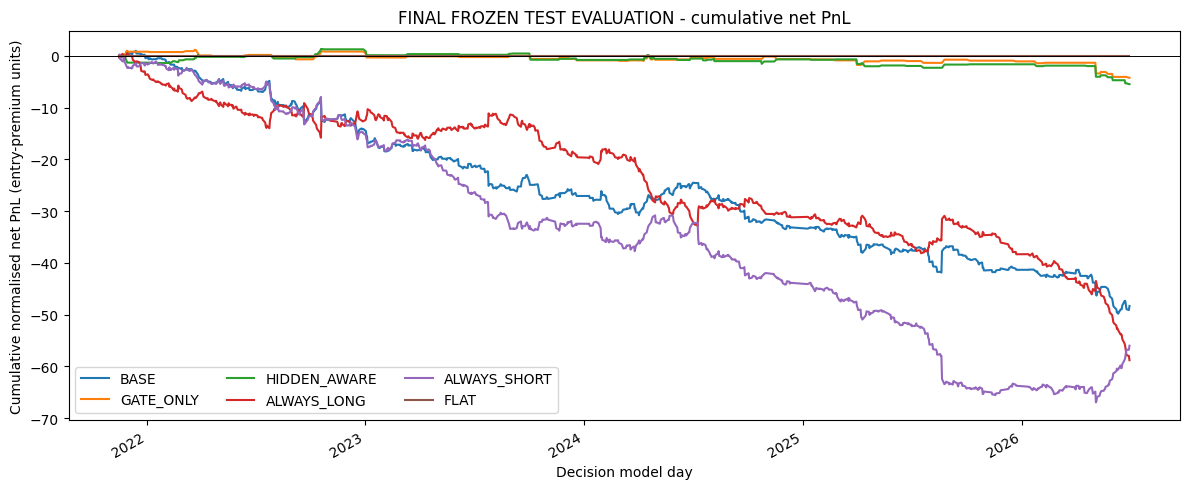

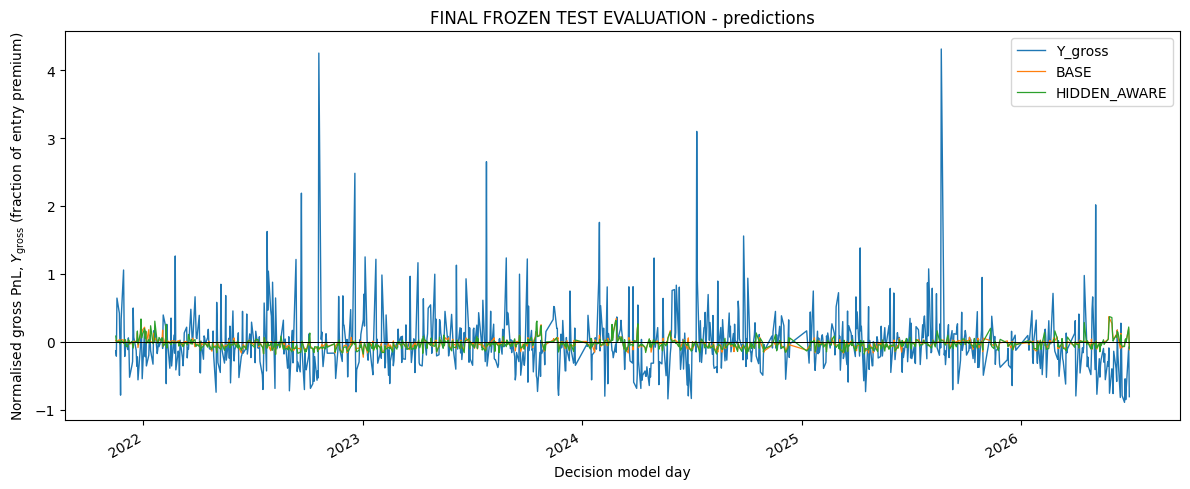

N25 FIGURE COSMETIC FIX
{'scientific_calculations_changed': 'NO', 'cumulative_title_corrected': 'YES', 'prediction_title_corrected': 'YES', 'visible_plot_mojibake': 'NONE', 'cumulative_y_label': 'Cumulative normalised net PnL (entry-premium units)', 'prediction_y_label': 'Normalised gross PnL, Y_gross (fraction of entry premium)', 'cumulative_x_label': 'Decision model day', 'prediction_x_label': 'Decision model day', 'cumulative_arrays_unchanged': 'PASS', 'prediction_arrays_unchanged': 'PASS', 'TEST_predictions_changed': 'NO', 'TEST_actions_changed': 'NO', 'TEST_PnLs_changed': 'NO', 'statistics_changed': 'NO', 'figures_refreshed': 'YES', 'execution_errors': 0}
N25 FIGURE LABELS CLEAN: YES


In [13]:
# Side-by-side stages from frozen N24 development outputs; no pooled statistic is computed.
common=read('24_application_common_feature_panel_pretest.csv',parse_dates=[KEY],usecols=[KEY,'stage','Y_gross'])
pm=read('24_predictive_metrics_pretest.csv'); bench=read('24_predictive_benchmark_pretest.csv'); ac=read('24_action_counts_pretest.csv'); ec=read('24_economic_diagnostics_pretest.csv')
rows=[]
for stage in ['C','VALIDATION']:
 q=common[common.stage.eq(stage)]; r={'stage':stage,'n':len(q),'mean_Y_gross':q.Y_gross.mean(),'median_Y_gross':q.Y_gross.median()}
 for name,label in [('ZERO_FORECAST','ZERO'),('BASE','BASE'),('HIDDEN_AWARE','HIDDEN_AWARE')]:
  src=bench if name=='ZERO_FORECAST' else pm; rr=src[(src.stage==stage)&(src.model==name)].iloc[0]; r[label+'_MSE']=rr.MSE; r[label+'_correlation']=rr.correlation
 for policy in ['BASE','GATE_ONLY','HIDDEN_AWARE']:
  aa=ac[(ac.stage==stage)&(ac.policy==policy)].iloc[0]; ee=ec[(ec.stage==stage)&(ec.policy==policy)].iloc[0]
  for x in ['n_long','n_flat','n_short']: r[policy+'_'+x]=aa[x]
  r[policy+'_cumulative_net_pnl']=ee.cumulative_net_pnl; r[policy+'_J']=ee.J
 rows.append(r)
r={'stage':'TEST','n':len(evalp),'mean_Y_gross':evalp.Y_gross.mean(),'median_Y_gross':evalp.Y_gross.median()}
for name,label in [('ZERO_FORECAST','ZERO'),('BASE','BASE'),('HIDDEN_AWARE','HIDDEN_AWARE')]:
 rr=predictive[predictive.model.eq(name)].iloc[0]; r[label+'_MSE']=rr.MSE; r[label+'_correlation']=rr.correlation
for policy in ['BASE','GATE_ONLY','HIDDEN_AWARE']:
 aa=actions[actions.policy.eq(policy)].iloc[0]; ee=economics[economics.policy.eq(policy)].iloc[0]
 for x in ['n_long','n_flat','n_short']: r[policy+'_'+x]=aa[x]
 r[policy+'_cumulative_net_pnl']=ee.cumulative_net_pnl; r[policy+'_J']=ee.J
rows.append(r); cross_stage=pd.DataFrame(rows); display(cross_stage)
plot_policies=['BASE','GATE_ONLY','HIDDEN_AWARE','ALWAYS_LONG','ALWAYS_SHORT','FLAT']
cumulative_plot_before={name:np.cumsum(pnl(pol[name])).copy() for name in plot_policies}
decision_days_before=evalp[KEY].to_numpy(copy=True)
fig,ax=plt.subplots(figsize=(12,5))
for name in plot_policies:
    ax.plot(evalp[KEY],cumulative_plot_before[name],label=name)
ax.axhline(0,color='black',lw=.7)
ax.legend(ncol=3)
ax.set_title('FINAL FROZEN TEST EVALUATION - cumulative net PnL')
ax.set_xlabel('Decision model day')
ax.set_ylabel('Cumulative normalised net PnL (entry-premium units)')
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIGURES/'25_final_test_cumulative_net_pnl.png',dpi=150); plt.show()
cumulative_plot_after={name:np.cumsum(pnl(pol[name])).copy() for name in plot_policies}
cumulative_plot_arrays_unchanged=bool(np.array_equal(evalp[KEY].to_numpy(),decision_days_before) and all(np.array_equal(cumulative_plot_before[name],cumulative_plot_after[name]) for name in plot_policies))

prediction_plot_before={'Y_gross':evalp.Y_gross.to_numpy(copy=True),'Yhat_BASE':evalp.Yhat_BASE.to_numpy(copy=True),'Yhat_HIDDEN_AWARE':evalp.Yhat_HIDDEN_AWARE.to_numpy(copy=True)}
prediction_days_before=evalp[KEY].to_numpy(copy=True)
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(evalp[KEY],prediction_plot_before['Y_gross'],label='Y_gross',lw=1)
ax.plot(evalp[KEY],prediction_plot_before['Yhat_BASE'],label='BASE',lw=.9)
ax.plot(evalp[KEY],prediction_plot_before['Yhat_HIDDEN_AWARE'],label='HIDDEN_AWARE',lw=.9)
ax.axhline(0,color='black',lw=.7); ax.legend()
ax.set_title('FINAL FROZEN TEST EVALUATION - predictions')
ax.set_xlabel('Decision model day')
ax.set_ylabel(r'Normalised gross PnL, $Y_{\mathrm{gross}}$ (fraction of entry premium)')
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIGURES/'25_final_test_predictions.png',dpi=150); plt.show()
prediction_plot_after={'Y_gross':evalp.Y_gross.to_numpy(copy=True),'Yhat_BASE':evalp.Yhat_BASE.to_numpy(copy=True),'Yhat_HIDDEN_AWARE':evalp.Yhat_HIDDEN_AWARE.to_numpy(copy=True)}
prediction_plot_arrays_unchanged=bool(np.array_equal(evalp[KEY].to_numpy(),prediction_days_before) and all(np.array_equal(prediction_plot_before[name],prediction_plot_after[name]) for name in prediction_plot_before))
assert cumulative_plot_arrays_unchanged and prediction_plot_arrays_unchanged
print('N25 FIGURE COSMETIC FIX')
print({'scientific_calculations_changed':'NO','cumulative_title_corrected':'YES','prediction_title_corrected':'YES','visible_plot_mojibake':'NONE','cumulative_y_label':'Cumulative normalised net PnL (entry-premium units)','prediction_y_label':'Normalised gross PnL, Y_gross (fraction of entry premium)','cumulative_x_label':'Decision model day','prediction_x_label':'Decision model day','cumulative_arrays_unchanged':'PASS','prediction_arrays_unchanged':'PASS','TEST_predictions_changed':'NO','TEST_actions_changed':'NO','TEST_PnLs_changed':'NO','statistics_changed':'NO','figures_refreshed':'YES','execution_errors':0})
print('N25 FIGURE LABELS CLEAN: YES')


## 25.14 Closure and exports

## 25.15 Final interpretation

In [14]:
# 25.14 Closure and exports: executable checks are separated from documented design/provenance statements.
HANDOFF_HASH_END=sha(HANDOFF); UP_AFTER={p.name:sha(p) for p in up}
reloaded_handoff=read('24_test_prediction_policy_handoff.csv',parse_dates=[KEY,'forecast_target_model_day']).sort_values(KEY).reset_index(drop=True)
reloaded_snapshot=reloaded_handoff[SNAP_COLS].copy().sort_values(KEY).reset_index(drop=True)
reloaded_float_equal=all(np.allclose(reloaded_snapshot[col],handoff_snapshot[col],rtol=0,atol=1e-12,equal_nan=True) for col in ['c_entry_L','c_entry_S',*PRED])
reloaded_discrete_equal=all(reloaded_snapshot[col].equals(handoff_snapshot[col]) for col in [KEY,'forecast_target_model_day','stage','G_t',*ACT])
reloaded_snapshot_equal=bool(reloaded_float_equal and reloaded_discrete_equal)
assert reloaded_snapshot_equal
closure_rows=[
 ('frozen_specification_exists_and_loads',SPEC.exists() and len(spec)==1),
 ('frozen_TEST_handoff_rows_901',len(handoff)==901),('unique_TEST_decision_days_901',handoff[KEY].nunique()==901),('handoff_stage_TEST_only',handoff.stage.eq('TEST').all()),
 ('TEST_outcome_merge_rows_901',len(evalp)==901),('no_duplicate_TEST_decision_keys',evalp[KEY].is_unique),('no_unmatched_frozen_decisions',len(evalp)==len(handoff)),
 ('all_frozen_predictions_finite',np.isfinite(handoff[PRED].to_numpy(float)).all()),('all_frozen_hurdles_finite',np.isfinite(handoff[['c_entry_L','c_entry_S']].to_numpy(float)).all()),
 ('z_GATE_ONLY_equals_z_BASE_times_G',bool((evalp.z_GATE_ONLY==evalp.z_BASE*evalp.G_t).all())),('z_HIDDEN_AWARE_equals_z_HIDDEN_RAW_times_G',bool((evalp.z_HIDDEN_AWARE==evalp.z_HIDDEN_RAW*evalp.G_t).all())),
 ('both_gated_arms_flat_outside_gate',bool((evalp.loc[evalp.G_t.eq(0),['z_GATE_ONLY','z_HIDDEN_AWARE']]==0).all().all())),
 ('post_merge_frozen_fields_equal_initial_snapshot',post_merge_snapshot_equal),('reloaded_handoff_equals_initial_snapshot',reloaded_snapshot_equal),
 ('ZERO_forecast_exactly_zero',np.array_equal(predictions['ZERO_FORECAST'],np.zeros(901))),('policy_pnl_mapping_all_arms',all(policy_mapping_checks.values())),
 ('handoff_SHA256_unchanged_during_N25',HANDOFF_HASH_START==HANDOFF_HASH_END),('upstream_N14_N24_notebook_SHA256_unchanged',UP_BEFORE==UP_AFTER),
 ('cross_stage_labels_separate',cross_stage.stage.tolist()==['C','VALIDATION','TEST'])]
closure=pd.DataFrame(closure_rows,columns=['check','pass']); assert closure['pass'].all()
design_provenance=pd.DataFrame([
 {'statement':'application_forecasting_models_fitted_in_N25','value':'NO (0)'},{'statement':'application_predictions_regenerated_in_N25','value':'NO (0)'},{'statement':'inferential_diagnostic_OLS_fits','value':'2'},
 {'statement':'TEST_driven_design_changes','value':'NO (0)'},{'statement':'C_VALIDATION_sources','value':'24_application_common_feature_panel_pretest.csv | 24_predictive_metrics_pretest.csv | 24_predictive_benchmark_pretest.csv | 24_action_counts_pretest.csv | 24_economic_diagnostics_pretest.csv'},
 {'statement':'pooled_primary_three_stage_result_used','value':'NO'},{'statement':'historical_TEST_globally_untouched','value':'NO'},{'statement':'revised_application_frozen_before_N25_outcome_evaluation','value':'YES'}])
prov=pre_outcome_audit.assign(handoff_sha256_end=HANDOFF_HASH_END,provenance_status=provenance_status,outcome_rows_loaded_after_gate=len(out),outcome_merge_rows=len(evalp),prior_N24_handoff_hash=prior_handoff_hash)
exports={'25_test_target_distribution.csv':target,'25_test_predictive_metrics.csv':predictive,'25_test_predictive_hierarchy.csv':hierarchy,'25_test_error_concentration.csv':concentration,'25_test_top_squared_errors.csv':top_errors,'25_test_action_counts.csv':actions,'25_test_economic_metrics.csv':economics,'25_test_gate_timing_diagnostic.csv':gate_timing,'25_test_gate_timing_bootstrap.csv':gate_bootstrap,'25_test_hidden_incremental_paired_diagnostic.csv':paired,'25_test_friction_diagnostic.csv':friction,'25_cross_stage_comparison.csv':cross_stage,'25_test_evaluation_panel.csv':evalp,'25_test_provenance_audit.csv':prov,'25_test_closure.csv':closure,'25_test_design_provenance.csv':design_provenance}
for name,df in exports.items(): df.to_csv(PROCESSED/name,index=False)
manifest25=pd.DataFrame([{'file':name,'rows':len(df),'exists':(PROCESSED/name).exists(),'sha256':sha(PROCESSED/name)} for name,df in exports.items()]); manifest25.to_csv(PROCESSED/'25_export_manifest.csv',index=False)
E=economics.set_index('policy'); A=actions.set_index('policy'); T=gate_timing.iloc[0]; D=paired.iloc[0]; C=concentration.set_index('model').loc['BASE']
case=[]
if zero<base and base<hidden and E.loc['FLAT','cumulative_net_pnl']>=max(E.loc['BASE','cumulative_net_pnl'],E.loc['GATE_ONLY','cumulative_net_pnl'],E.loc['HIDDEN_AWARE','cumulative_net_pnl']): case.append('TEST provides additional evidence consistent with the pre-TEST null: frozen learned forecasts do not establish predictive or economic value beyond the no-edge benchmark, and hidden-response coordinates do not provide incremental value.')
if base<zero and not hidden<base: case.append('The ordinary-information model exhibits TEST predictive value relative to the no-edge benchmark, but hidden-response coordinates do not establish incremental predictive value.')
if hidden<base and E.loc['HIDDEN_AWARE','cumulative_net_pnl']<=E.loc['GATE_ONLY','cumulative_net_pnl']: case.append('Hidden-response coordinates contain incremental predictive information on TEST, but this does not translate into incremental realised economic value after frozen deployment and costs.')
if E.loc['BASE','cumulative_net_pnl']<0 and E.loc['GATE_ONLY','cumulative_net_pnl']<0 and E.loc['HIDDEN_AWARE','cumulative_net_pnl']<0: case.append('Adverse TEST performance provides further evidence consistent with weak or non-robust economic value under the frozen application design.')
if not case: case.append('The frozen TEST evidence is mixed and is reported separately from adverse VALIDATION evidence; no stable economic relationship is claimed.')
print('N25 FINAL FROZEN TEST EVALUATION')
print({'handoff_rows':len(handoff),'matched_rows':len(evalp),'gate_rows':int(evalp.G_t.sum()),'mean_Ygross':float(evalp.Y_gross.mean()),'median_Ygross':float(evalp.Y_gross.median()),'ZERO_MSE':zero,'BASE_MSE':base,'HIDDEN_MSE':hidden,'BASE_minus_ZERO':base-zero,'HIDDEN_minus_BASE':hidden-base,'HIDDEN_pct_vs_BASE':(hidden-base)/base*100,'BASE_corr':float(predictive.loc[predictive.model.eq('BASE'),'correlation'].iloc[0]),'HIDDEN_corr':float(predictive.loc[predictive.model.eq('HIDDEN_AWARE'),'correlation'].iloc[0])})
print('Noise MSE:',dict(zip(predictive[predictive.model.str.contains('NOISE')].model,predictive[predictive.model.str.contains('NOISE')].MSE)))
print('Hierarchy:',hierarchy.model.tolist()); print('Actions:',A[['n_long','n_flat','n_short']].loc[['BASE','GATE_ONLY','HIDDEN_AWARE']].to_dict(orient='index')); print('Cumulative PnL:',E.cumulative_net_pnl.to_dict()); print('J:',E.J.loc[['BASE','GATE_ONLY','HIDDEN_AWARE']].to_dict())
print('Gate timing:',T.to_dict()); print('Bootstrap interval:',gate_bootstrap.iloc[0][['p02_5','p97_5']].to_dict()); print('Paired hidden incremental:',D.to_dict()); print('Friction:',friction.iloc[0].to_dict())
print('Provenance:',prov[['provenance_status','handoff_sha256_start','handoff_sha256_end']].to_dict(orient='records')); print('Execution errors: 0; application forecasting models fitted: 0; application predictions regenerated: 0; inferential diagnostic OLS fits: 2; TEST-driven design changes: 0; upstream notebooks modified: NONE')
display(Markdown('**Frozen-design interpretation.** '+' '.join(case)+' The ZERO_FORECAST and FLAT benchmarks are closely aligned: a zero expected gross-edge forecast lies inside the frozen entry-known-cost hurdle and implies no trade; predictive MSE and realised PnL remain distinct metrics. The substantial BASE-to-GATE_ONLY full-period difference primarily reflects reduced exposure: conditional on BASE trading, gated and non-gated days have nearly identical mean realised performance in the supporting HAC diagnostic. On the same frozen gate, GATED_ALWAYS_SHORT outperforms both GATE_ONLY and HIDDEN_AWARE in cumulative TEST net PnL, so the learned gated policies do not establish incremental value relative to that frozen benchmark. The supporting confidence intervals are wide and do not rule out moderate economically relevant effects. The evidence is a failure to establish robust tradable value under the frozen design, not proof that the true effect is exactly zero. Gate timing and paired effects are associations, not causal estimates.'))
print('N25 FINAL WRITE-UP FREEZE')
print({'scientific_calculations_changed_in_cleanup':'NO','predictions_changed':'NO','actions_changed':'NO','economic_PnLs_changed':'NO','HAC_gate_diagnostic_changed':'NO','gated_hidden_HAC_diagnostic_changed':'NO','moving_block_bootstrap_changed':'NO','unsupported_primary_inference_wording_removed':'YES','inferential_diagnostics_labelled_supporting':'YES','pooled_HAC_regression_added':'NO','all_901_posthoc_gate_regression_added':'NO','MDE_calculation_added':'NO','entry_hurdle_entry_known_cost_rule':'YES','future_realised_hedge_costs_distinguished':'YES','gated_always_short_benchmark_interpretation_included':'YES','moderate_effects_not_ruled_out_wording_included':'YES','broken_unicode_removed':'YES','vacuous_GATE_ONLY_string_assertion_absent':'YES','frozen_handoff_integrity_checks':'PASS','genuine_closure_checks':'PASS','handoff_hash_unchanged':'YES','upstream_N14_N24_modified':'NONE','TEST_driven_model_or_policy_changes':0,'execution_errors':0})
print('N25 PERMANENTLY FROZEN FOR WRITE-UP: YES')


N25 FINAL FROZEN TEST EVALUATION
{'handoff_rows': 901, 'matched_rows': 901, 'gate_rows': 74, 'mean_Ygross': -0.0015522137406160125, 'median_Ygross': -0.0628809498540639, 'ZERO_MSE': 0.2180518737403822, 'BASE_MSE': 0.22344653544647103, 'HIDDEN_MSE': 0.224951558908172, 'BASE_minus_ZERO': 0.005394661706088821, 'HIDDEN_minus_BASE': 0.0015050234617009772, 'HIDDEN_pct_vs_BASE': 0.6735496966617867, 'BASE_corr': -0.003138661885844992, 'HIDDEN_corr': -0.005833358801682481}
Noise MSE: {'BASE_NOISE_19': 0.22215735635986283, 'BASE_NOISE_119': 0.22251926053036494, 'BASE_NOISE_219': 0.2252250697064249}
Hierarchy: ['ZERO_FORECAST', 'BASE_NOISE_19', 'BASE_NOISE_119', 'BASE', 'HIDDEN_AWARE', 'BASE_NOISE_219']
Actions: {'BASE': {'n_long': 203, 'n_flat': 181, 'n_short': 517}, 'GATE_ONLY': {'n_long': 24, 'n_flat': 837, 'n_short': 40}, 'HIDDEN_AWARE': {'n_long': 25, 'n_flat': 832, 'n_short': 44}}
Cumulative PnL: {'BASE': -48.33861972662587, 'GATE_ONLY': -4.251241982588201, 'HIDDEN_AWARE': -5.48549591163928

**Frozen-design interpretation.** TEST provides additional evidence consistent with the pre-TEST null: frozen learned forecasts do not establish predictive or economic value beyond the no-edge benchmark, and hidden-response coordinates do not provide incremental value. Adverse TEST performance provides further evidence consistent with weak or non-robust economic value under the frozen application design. The ZERO_FORECAST and FLAT benchmarks are closely aligned: a zero expected gross-edge forecast lies inside the frozen entry-known-cost hurdle and implies no trade; predictive MSE and realised PnL remain distinct metrics. The substantial BASE-to-GATE_ONLY full-period difference primarily reflects reduced exposure: conditional on BASE trading, gated and non-gated days have nearly identical mean realised performance in the supporting HAC diagnostic. On the same frozen gate, GATED_ALWAYS_SHORT outperforms both GATE_ONLY and HIDDEN_AWARE in cumulative TEST net PnL, so the learned gated policies do not establish incremental value relative to that frozen benchmark. The supporting confidence intervals are wide and do not rule out moderate economically relevant effects. The evidence is a failure to establish robust tradable value under the frozen design, not proof that the true effect is exactly zero. Gate timing and paired effects are associations, not causal estimates.

N25 FINAL WRITE-UP FREEZE
{'scientific_calculations_changed_in_cleanup': 'NO', 'predictions_changed': 'NO', 'actions_changed': 'NO', 'economic_PnLs_changed': 'NO', 'HAC_gate_diagnostic_changed': 'NO', 'gated_hidden_HAC_diagnostic_changed': 'NO', 'moving_block_bootstrap_changed': 'NO', 'unsupported_primary_inference_wording_removed': 'YES', 'inferential_diagnostics_labelled_supporting': 'YES', 'pooled_HAC_regression_added': 'NO', 'all_901_posthoc_gate_regression_added': 'NO', 'MDE_calculation_added': 'NO', 'entry_hurdle_entry_known_cost_rule': 'YES', 'future_realised_hedge_costs_distinguished': 'YES', 'gated_always_short_benchmark_interpretation_included': 'YES', 'moderate_effects_not_ruled_out_wording_included': 'YES', 'broken_unicode_removed': 'YES', 'vacuous_GATE_ONLY_string_assertion_absent': 'YES', 'frozen_handoff_integrity_checks': 'PASS', 'genuine_closure_checks': 'PASS', 'handoff_hash_unchanged': 'YES', 'upstream_N14_N24_modified': 'NONE', 'TEST_driven_model_or_policy_changes': 